# Geometry Separation of Ground-Truth 0 vs 1 Scans from Mongo

This notebook analyzes whether the geometry of saved scans consistently differs between `ground_truth=0` and `ground_truth=1`.

It focuses on:
- direct geometry metrics per layer: centroid shift, spread, Fisher-style separation, energy distance, MMD, and subspace similarity
- stability checks: stratified CV, balanced subsamples, bootstrap confidence intervals
- trajectory-level analysis: per-layer AUC, cumulative AUC, prototype-distance separation, optional DTW, and 2D trajectory visualization

Use `LAYER_NAME_FILTER = "SelfAttention.o"` for attention outputs or `"DenseReluDense.wo"` for FF activation outputs.

In [23]:
import os
import sys
import tempfile

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import pairwise_distances, rbf_kernel

from neuralsignal.backend.ns_backend import NSBackend
from neuralsignal.core.modules.neuralsignal_config import sdk_config

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [24]:
# Mongo / dataset config
APPLICATION_NAME = "HaluBench"
SUB_APPLICATION_NAME = "GranularAttentioAndWO"

# APPLICATION_NAME = "redis"
# SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

# Extra filters beyond ground truth. Keep empty if not needed.
BASE_QUERY = {}
GROUND_TRUTH_0_QUERY = {"ground_truth": {"$in": [0, "0", False]}}
GROUND_TRUTH_1_QUERY = {"ground_truth": {"$in": [1, "1", True]}}

# Analysis target
LAYER_NAME_FILTER = "SelfAttention.o"   # or "DenseReluDense.wo"
TOKEN_SELECTION = "last"                # one of: last, mean

# Sampling / compute limits
MAX_SCANS_PER_CLASS = 120
RANDOM_STATE = 7
CV_FOLDS = 5
BALANCED_SUBSAMPLE_ROUNDS = 32
BOOTSTRAP_ROUNDS = 64
SUBSPACE_COMPONENTS = 5
PER_LAYER_PCA_COMPONENTS = 16
CUMULATIVE_PCA_COMPONENTS = 32
RUN_DTW_TRAJECTORY = False

LABEL_0 = "ground_truth=0"
LABEL_1 = "ground_truth=1"

In [25]:
backend_cfg = sdk_config.get_backend_config().copy()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

def merged_query(*parts):
    out = {}
    for p in parts:
        out.update(p)
    return out

def load_scans_by_query(ns_backend, query, limit=0):
    cursor = ns_backend.query(query)
    if limit and limit > 0:
        cursor = cursor.limit(limit)
    scans = []
    skipped = 0
    for doc in cursor:
        try:
            scans.append(ns_backend.deserialize_scan(doc))
        except Exception:
            skipped += 1
    return scans, skipped

query_0 = merged_query(BASE_QUERY, GROUND_TRUTH_0_QUERY)
query_1 = merged_query(BASE_QUERY, GROUND_TRUTH_1_QUERY)

group_0, skipped_0 = load_scans_by_query(be, query_0, MAX_SCANS_PER_CLASS)
group_1, skipped_1 = load_scans_by_query(be, query_1, MAX_SCANS_PER_CLASS)

print(f"{LABEL_0}: loaded {len(group_0)} scans  (skipped {skipped_0})")
print(f"{LABEL_1}: loaded {len(group_1)} scans  (skipped {skipped_1})")
print(f"Layer filter: {LAYER_NAME_FILTER}")

ground_truth=0: loaded 120 scans  (skipped 0)
ground_truth=1: loaded 120 scans  (skipped 0)
Layer filter: SelfAttention.o


In [26]:
def get_mongo_backend(ns_backend):
    backend = ns_backend.backend
    if hasattr(backend, "col"):
        return backend
    if hasattr(backend, "mng"):
        return backend.mng
    raise TypeError("Configured backend does not expose a Mongo collection.")

mongo_backend = get_mongo_backend(be)
print(f"Mongo db         : {mongo_backend.db.name}")
print(f"Mongo collection : {mongo_backend.col.name}")
print(f"Total docs       : {mongo_backend.col.count_documents({})}")
print(f"Class-0 query ct : {mongo_backend.col.count_documents(query_0)}")
print(f"Class-1 query ct : {mongo_backend.col.count_documents(query_1)}")

sample_docs = list(mongo_backend.col.find({}, {"ground_truth": 1, "decoded_output": 1, "metadata": 1}).limit(5))
sample_docs

Mongo db         : HaluBench
Mongo collection : GranularAttentioAndWO
Total docs       : 1000
Class-0 query ct : 500
Class-1 query ct : 500


[{'_id': ObjectId('69bf0e32ad24d9148050eba0'),
  'ground_truth': 0,
  'decoded_output': 'false',
  'metadata': {'source_ds': 'DROP'}},
 {'_id': ObjectId('69bf0e35ad24d9148050ee31'),
  'ground_truth': 0,
  'decoded_output': 'true',
  'metadata': {'source_ds': 'DROP'}},
 {'_id': ObjectId('69bf0e39ad24d9148050f116'),
  'ground_truth': 0,
  'decoded_output': 'true',
  'metadata': {'source_ds': 'DROP'}},
 {'_id': ObjectId('69bf0e3cad24d9148050f418'),
  'ground_truth': 0,
  'decoded_output': 'true',
  'metadata': {'source_ds': 'DROP'}},
 {'_id': ObjectId('69bf0e3fad24d9148050f6b4'),
  'ground_truth': 0,
  'decoded_output': 'true',
  'metadata': {'source_ds': 'DROP'}}]

In [27]:
rng = np.random.default_rng(RANDOM_STATE)

def vectorize_tensor(tensor, token_selection="last"):
    t = tensor.float().cpu()
    if t.ndim == 1:
        return t.numpy()
    if t.ndim != 2:
        raise ValueError(f"Expected 1D or 2D tensor, got shape {tuple(t.shape)}")
    if token_selection == "last":
        return t[-1].numpy()
    if token_selection == "mean":
        return t.mean(dim=0).numpy()
    raise ValueError(f"Unsupported TOKEN_SELECTION={token_selection}")

def get_matching_layers(scan, layer_name_filter):
    matches = []
    for layer_id in scan["layer_order"]:
        layer_name = scan["layer_id_to_name"][layer_id]
        if layer_name_filter in layer_name:
            matches.append((layer_id, layer_name, f"L{len(matches):02d}"))
    if not matches:
        raise ValueError(f"No layers matched filter '{layer_name_filter}'")
    return matches

def build_scan_tensor(scans, expected_layers, token_selection="last"):
    valid = []
    ids = []
    dropped = 0
    target_dim = None
    for scan in scans:
        try:
            rows = []
            for layer_id, _, _ in expected_layers:
                vec = vectorize_tensor(scan["outputs"][layer_id], token_selection=token_selection)
                rows.append(vec)
            mat = np.stack(rows, axis=0)
            if target_dim is None:
                target_dim = mat.shape[1]
            if mat.shape[1] != target_dim:
                dropped += 1
                continue
            valid.append(mat)
            ids.append(str(scan.get("_id", len(ids))))
        except Exception:
            dropped += 1
    if not valid:
        raise ValueError("No valid scans after extraction.")
    return np.stack(valid, axis=0), ids, dropped

def choose_reference_scan(group_a, group_b, layer_name_filter):
    for scan in list(group_a) + list(group_b):
        try:
            return get_matching_layers(scan, layer_name_filter)
        except Exception:
            pass
    raise ValueError("Could not find any scan with matching layers.")

reference_layers = choose_reference_scan(group_0, group_1, LAYER_NAME_FILTER)
X0, ids0, dropped0 = build_scan_tensor(group_0, reference_layers, token_selection=TOKEN_SELECTION)
X1, ids1, dropped1 = build_scan_tensor(group_1, reference_layers, token_selection=TOKEN_SELECTION)

layer_labels = [label for _, _, label in reference_layers]
layer_names = [name for _, name, _ in reference_layers]

print(f"{LABEL_0}: tensor {X0.shape}  dropped {dropped0}")
print(f"{LABEL_1}: tensor {X1.shape}  dropped {dropped1}")
print(f"Matched layers: {len(layer_labels)}")
print(f"Hidden dim    : {X0.shape[2]}")

ground_truth=0: tensor (120, 48, 1024)  dropped 0
ground_truth=1: tensor (120, 48, 1024)  dropped 0
Matched layers: 48
Hidden dim    : 1024


In [28]:
def sample_balanced(Xa, Xb, rng_local):
    n = min(len(Xa), len(Xb))
    ia = rng_local.choice(len(Xa), size=n, replace=False)
    ib = rng_local.choice(len(Xb), size=n, replace=False)
    return Xa[ia], Xb[ib]

def bootstrap_balanced(Xa, Xb, rng_local):
    n = min(len(Xa), len(Xb))
    ia = rng_local.choice(len(Xa), size=n, replace=True)
    ib = rng_local.choice(len(Xb), size=n, replace=True)
    return Xa[ia], Xb[ib]

def covariance_trace(X):
    if len(X) < 2:
        return np.nan
    return np.var(X, axis=0, ddof=1).sum()

def energy_distance(Xa, Xb):
    d_ab = pairwise_distances(Xa, Xb, metric="euclidean").mean()
    d_aa = pairwise_distances(Xa, Xa, metric="euclidean")
    d_bb = pairwise_distances(Xb, Xb, metric="euclidean")
    aa = d_aa[~np.eye(len(Xa), dtype=bool)].mean() if len(Xa) > 1 else 0.0
    bb = d_bb[~np.eye(len(Xb), dtype=bool)].mean() if len(Xb) > 1 else 0.0
    return 2.0 * d_ab - aa - bb

def mmd_rbf(Xa, Xb):
    pooled = np.vstack([Xa, Xb])
    dists = pairwise_distances(pooled, metric="euclidean")
    positive = dists[np.isfinite(dists) & (dists > 0)]
    if positive.size == 0:
        sigma = 1.0
    else:
        sigma = float(np.median(positive))
        if not np.isfinite(sigma) or sigma <= 0:
            sigma = float(np.mean(positive))
        if not np.isfinite(sigma) or sigma <= 0:
            sigma = 1.0
    gamma = float(1.0 / max(2.0 * sigma * sigma, 1e-12))
    kaa = rbf_kernel(Xa, Xa, gamma=gamma)
    kbb = rbf_kernel(Xb, Xb, gamma=gamma)
    kab = rbf_kernel(Xa, Xb, gamma=gamma)
    return float(kaa.mean() + kbb.mean() - 2.0 * kab.mean())

def principal_angles_and_subspace_cka(Xa, Xb, max_components=5):
    k = min(max_components, Xa.shape[0] - 1, Xb.shape[0] - 1, Xa.shape[1], Xb.shape[1])
    if k < 1:
        return np.nan, np.nan
    pa = PCA(n_components=k, random_state=RANDOM_STATE).fit(Xa).components_
    pb = PCA(n_components=k, random_state=RANDOM_STATE).fit(Xb).components_
    svals = np.linalg.svd(pa @ pb.T, compute_uv=False)
    svals = np.clip(svals, -1.0, 1.0)
    angles = np.degrees(np.arccos(svals))
    cka = np.linalg.norm(pa @ pb.T, ord="fro") ** 2 / k
    return float(angles.mean()), float(cka)

def layer_geometry_metrics(Xa, Xb, max_components=5):
    mu_a = Xa.mean(axis=0)
    mu_b = Xb.mean(axis=0)
    delta = mu_b - mu_a
    delta_norm = np.linalg.norm(delta)
    between_sq = float(delta_norm ** 2)
    norm_a = np.linalg.norm(mu_a)
    norm_b = np.linalg.norm(mu_b)
    centroid_cos = float(np.dot(mu_a, mu_b) / max(norm_a * norm_b, 1e-12))

    tr_a = covariance_trace(Xa)
    tr_b = covariance_trace(Xb)
    pooled_within = 0.5 * (tr_a + tr_b)
    between_to_within = float(between_sq / max(pooled_within, 1e-12))

    direction = delta / max(delta_norm, 1e-12)
    proj_a = Xa @ direction
    proj_b = Xb @ direction
    fisher_ratio = float(between_sq / max(np.var(proj_a, ddof=1) + np.var(proj_b, ddof=1), 1e-12))

    mean_angle_deg, subspace_cka = principal_angles_and_subspace_cka(Xa, Xb, max_components=max_components)

    return {
        "centroid_distance": float(delta_norm),
        "centroid_cosine": centroid_cos,
        "within_trace_class0": float(tr_a),
        "within_trace_class1": float(tr_b),
        "pooled_within_trace": float(pooled_within),
        "between_centroid_sq": between_sq,
        "between_to_within": between_to_within,
        "fisher_ratio": fisher_ratio,
        "energy_distance": float(energy_distance(Xa, Xb)),
        "mmd_rbf": float(mmd_rbf(Xa, Xb)),
        "mean_principal_angle_deg": mean_angle_deg,
        "subspace_cka": subspace_cka,
    }

def summarize_metric_stability(Xa_layer, Xb_layer, metric_names, seed_offset=0):
    subsample_rows = []
    boot_rows = []
    for i in range(BALANCED_SUBSAMPLE_ROUNDS):
        ra, rb = sample_balanced(Xa_layer, Xb_layer, np.random.default_rng(RANDOM_STATE + seed_offset + i))
        subsample_rows.append(layer_geometry_metrics(ra, rb, max_components=SUBSPACE_COMPONENTS))
    for i in range(BOOTSTRAP_ROUNDS):
        ra, rb = bootstrap_balanced(Xa_layer, Xb_layer, np.random.default_rng(1000 + RANDOM_STATE + seed_offset + i))
        boot_rows.append(layer_geometry_metrics(ra, rb, max_components=SUBSPACE_COMPONENTS))

    subs_df = pd.DataFrame(subsample_rows)
    boot_df = pd.DataFrame(boot_rows)
    summary = {}
    for name in metric_names:
        summary[f"{name}_subsample_mean"] = float(subs_df[name].mean())
        summary[f"{name}_subsample_std"] = float(subs_df[name].std(ddof=1))
        summary[f"{name}_boot_ci_low"] = float(boot_df[name].quantile(0.025))
        summary[f"{name}_boot_ci_high"] = float(boot_df[name].quantile(0.975))
    return summary

metric_names = [
    "centroid_distance",
    "centroid_cosine",
    "pooled_within_trace",
    "between_to_within",
    "fisher_ratio",
    "energy_distance",
    "mmd_rbf",
    "mean_principal_angle_deg",
    "subspace_cka",
]

In [29]:
rows = []
for layer_idx, layer_label in enumerate(layer_labels):
    Xa = X0[:, layer_idx, :]
    Xb = X1[:, layer_idx, :]
    base = layer_geometry_metrics(Xa, Xb, max_components=SUBSPACE_COMPONENTS)
    stable = summarize_metric_stability(Xa, Xb, metric_names, seed_offset=100 * layer_idx)
    rows.append({
        "layer_idx": layer_idx,
        "layer_label": layer_label,
        "layer_name": layer_names[layer_idx],
        **base,
        **stable,
    })

geometry_df = pd.DataFrame(rows)
geometry_df.head()

,layer_idx,layer_label,layer_name,centroid_distance,centroid_cosine,within_trace_class0,within_trace_class1,pooled_within_trace,between_centroid_sq,between_to_within,fisher_ratio,energy_distance,mmd_rbf,mean_principal_angle_deg,subspace_cka,centroid_distance_subsample_mean,centroid_distance_subsample_std,centroid_distance_boot_ci_low,centroid_distance_boot_ci_high,centroid_cosine_subsample_mean,centroid_cosine_subsample_std,centroid_cosine_boot_ci_low,centroid_cosine_boot_ci_high,pooled_within_trace_subsample_mean,pooled_within_trace_subsample_std,pooled_within_trace_boot_ci_low,pooled_within_trace_boot_ci_high,between_to_within_subsample_mean,between_to_within_subsample_std,between_to_within_boot_ci_low,between_to_within_boot_ci_high,fisher_ratio_subsample_mean,fisher_ratio_subsample_std,fisher_ratio_boot_ci_low,fisher_ratio_boot_ci_high,energy_distance_subsample_mean,energy_distance_subsample_std,energy_distance_boot_ci_low,energy_distance_boot_ci_high,mmd_rbf_subsample_mean,mmd_rbf_subsample_std,mmd_rbf_boot_ci_low,mmd_rbf_boot_ci_high,mean_principal_angle_deg_subsample_mean,mean_principal_angle_deg_subsample_std,mean_principal_angle_deg_boot_ci_low,mean_principal_angle_deg_boot_ci_high,subspace_cka_subsample_mean,subspace_cka_subsample_std,subspace_cka_boot_ci_low,subspace_cka_boot_ci_high
0,0,L00,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,4.889917,0.999131,243.042450,268.270142,255.656296,23.911287,0.093529,0.167457,1.407646,0.035169,43.051483,0.545746,4.889916,1.614764e-06,3.771829,7.517000,0.999131,4.442220e-08,0.997954,0.999469,255.656296,0.000004,239.341619,268.930066,0.093529,6.174252e-08,0.054983,0.231039,0.167457,1.855155e-07,0.139101,0.388254,1.407640,3.020036e-06,1.091063,2.912527,0.035170,1.266104e-07,0.025899,0.072901,43.051524,0.000023,38.544647,48.778699,0.545745,1.628826e-07,0.470610,0.597456
1,1,L01,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,4.199968,0.997441,111.255707,166.437592,138.846649,17.639730,0.127045,0.305295,1.219959,0.043152,31.820923,0.707680,4.199968,1.361470e-06,3.319461,5.746366,0.997441,3.294167e-08,0.995274,0.998413,138.846652,0.000006,127.859928,152.625766,0.127045,8.363122e-08,0.078738,0.243655,0.305295,1.783326e-07,0.222188,0.594004,1.219958,2.316309e-06,0.936574,2.202041,0.043152,7.635746e-08,0.032623,0.075316,31.820928,0.000028,29.462774,43.823548,0.707680,2.560058e-07,0.543555,0.727828
2,2,L02,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,3.658485,0.995144,104.180748,126.260109,115.220428,13.384510,0.116164,0.235017,0.990096,0.037270,35.156715,0.639286,3.658484,4.150983e-07,2.523828,4.841204,0.995144,7.531853e-08,0.991571,0.997667,115.220430,0.000003,107.609984,121.896945,0.116164,2.682071e-08,0.056678,0.210536,0.235017,7.677259e-08,0.180738,0.457545,0.990095,1.076509e-06,0.639513,1.746058,0.037270,6.201231e-07,0.022446,0.064307,35.156654,0.000039,35.665280,44.980905,0.639286,5.593461e-07,0.518882,0.637986
3,3,L03,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,3.389555,0.996522,77.374016,97.617401,87.495712,11.489084,0.131310,0.257470,0.899330,0.037521,41.841789,0.569085,3.389555,9.665656e-07,2.700664,4.929693,0.996522,7.560329e-08,0.992676,0.997805,87.495709,0.000004,81.413220,91.308982,0.131310,7.753126e-08,0.083167,0.280867,0.257470,1.171448e-07,0.198927,0.498732,0.899331,9.454674e-07,0.697855,1.850366,0.037521,1.096315e-07,0.026340,0.074223,41.841980,0.000176,39.206333,49.454384,0.569084,7.962850e-07,0.466605,0.586160
4,4,L04,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,3.157039,0.997526,91.993736,107.154297,99.574020,9.966895,0.100095,0.272664,0.847113,0.032012,45.105305,0.504052,3.157038,5.581154e-07,2.432602,4.559092,0.997526,5.244510e-08,0.994853,0.998548,99.574018,0.000004,94.976874,102.752438,0.100095,3.770679e-08,0.059765,0.217732,0.272664,1.442116e-07,0.254651,0.556390,0.847112,1.404315e-06,0.660465,1.741915,0.032012,5.549751e-08,0.021516,0.065612,45.105333,0.000172,42.310158,52.252910,0.504052,1.276817e-06,0.419863,0.534251


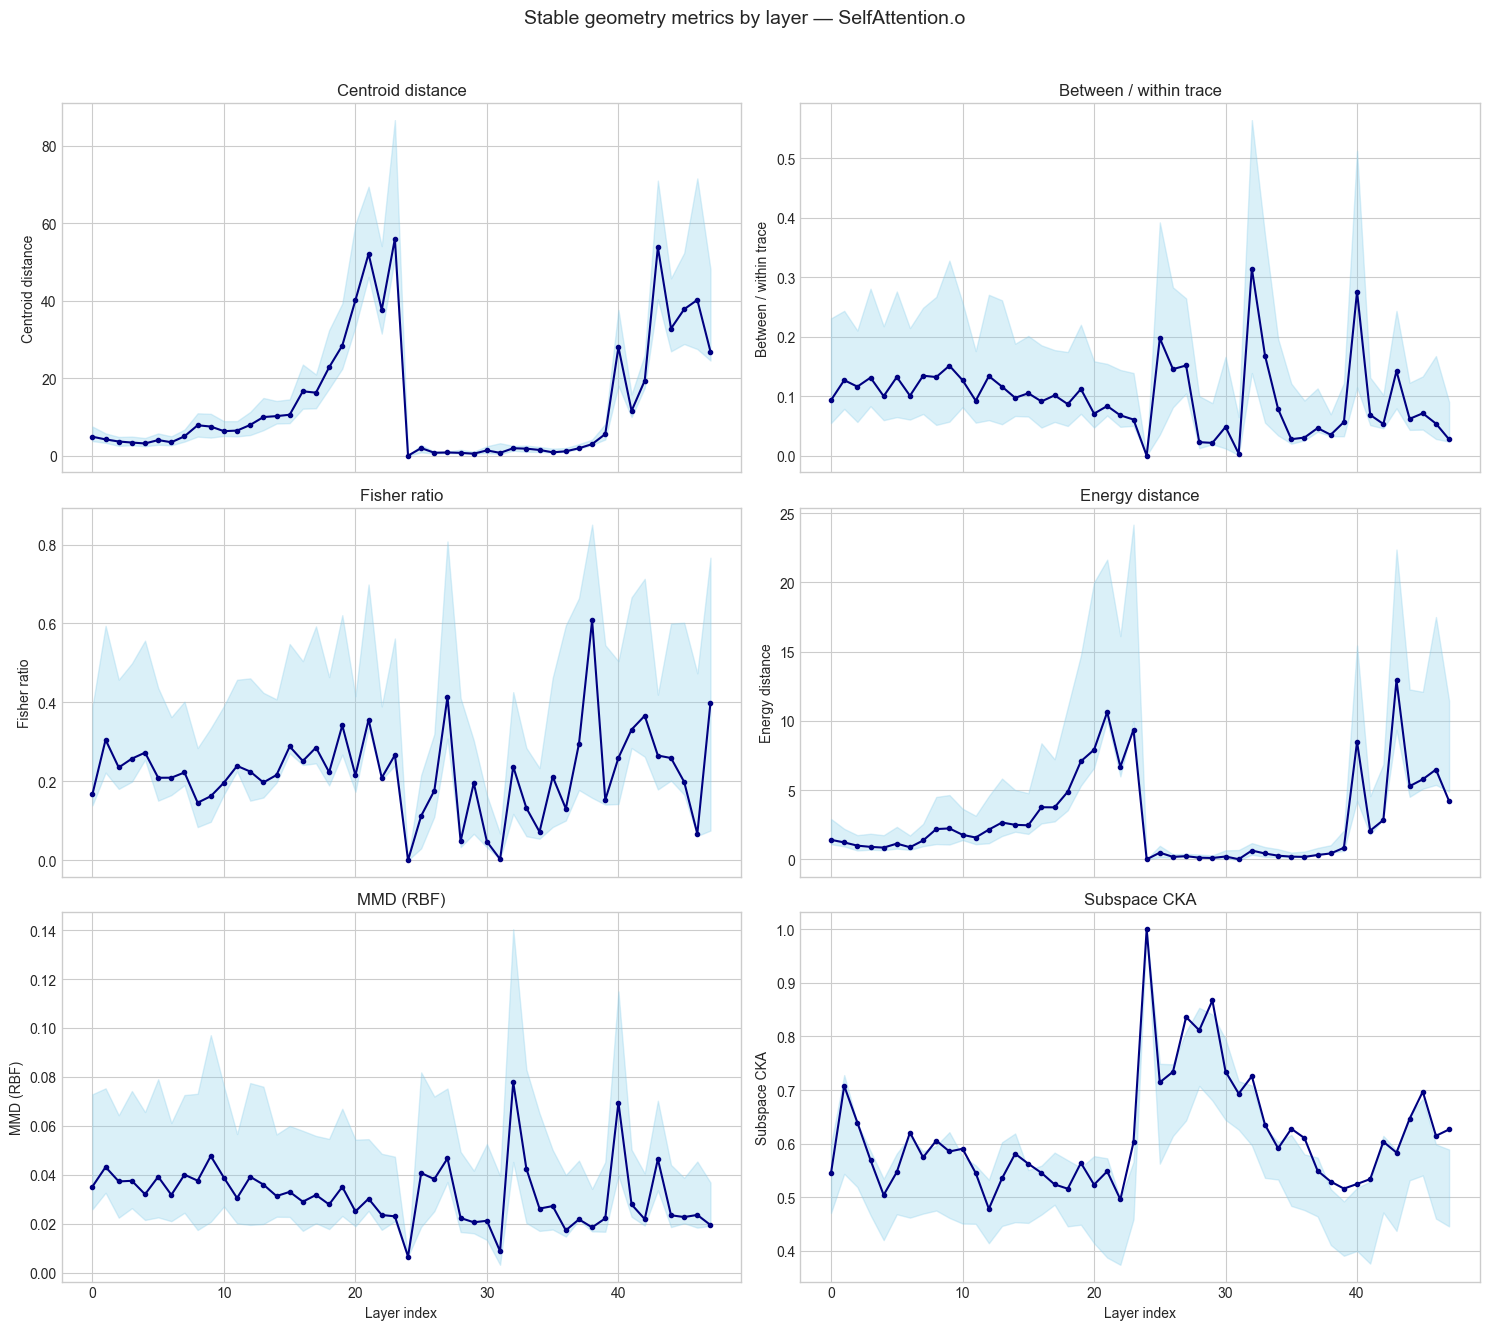

,layer_idx,layer_label,layer_name,centroid_distance_subsample_mean,between_to_within_subsample_mean,fisher_ratio_subsample_mean,energy_distance_subsample_mean,mmd_rbf_subsample_mean,subspace_cka_subsample_mean,mean_principal_angle_deg_subsample_mean
38,38,L38,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,2.985819,0.035195,0.607779,0.426002,0.018484,0.529140,44.022997
27,27,L27,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.829763,0.151775,0.414063,0.231150,0.046674,0.836259,21.838158
47,47,L47,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,26.853655,0.027437,0.399039,4.205367,0.019452,0.626428,35.636462
42,42,L42,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,19.364013,0.053322,0.366131,2.837218,0.021855,0.603514,40.505448
21,21,L21,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,52.064931,0.083572,0.356351,10.631613,0.030211,0.548282,44.361148
19,19,L19,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,28.403125,0.112104,0.341690,7.080118,0.035046,0.563931,40.062794
41,41,L41,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,11.565234,0.068607,0.331195,2.072885,0.027864,0.533810,42.348001
1,1,L01,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,4.199968,0.127045,0.305295,1.219958,0.043152,0.707680,31.820928
37,37,L37,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,1.922376,0.046430,0.295305,0.314263,0.021770,0.549257,42.435143
15,15,L15,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,10.561273,0.105048,0.288356,2.458755,0.033006,0.562419,42.218852


In [30]:
fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=True)
x = geometry_df["layer_idx"].to_numpy()

plots = [
    ("centroid_distance_subsample_mean", "centroid_distance_boot_ci_low", "centroid_distance_boot_ci_high", "Centroid distance"),
    ("between_to_within_subsample_mean", "between_to_within_boot_ci_low", "between_to_within_boot_ci_high", "Between / within trace"),
    ("fisher_ratio_subsample_mean", "fisher_ratio_boot_ci_low", "fisher_ratio_boot_ci_high", "Fisher ratio"),
    ("energy_distance_subsample_mean", "energy_distance_boot_ci_low", "energy_distance_boot_ci_high", "Energy distance"),
    ("mmd_rbf_subsample_mean", "mmd_rbf_boot_ci_low", "mmd_rbf_boot_ci_high", "MMD (RBF)"),
    ("subspace_cka_subsample_mean", "subspace_cka_boot_ci_low", "subspace_cka_boot_ci_high", "Subspace CKA"),
]

for ax, (mean_col, low_col, high_col, title) in zip(axes.ravel(), plots):
    mean = geometry_df[mean_col].to_numpy()
    low = geometry_df[low_col].to_numpy()
    high = geometry_df[high_col].to_numpy()
    ax.plot(x, mean, color="navy", marker="o", markersize=3)
    ax.fill_between(x, low, high, color="skyblue", alpha=0.3)
    ax.set_title(title)
    ax.set_ylabel(title)

axes[-1, 0].set_xlabel("Layer index")
axes[-1, 1].set_xlabel("Layer index")
plt.suptitle(f"Stable geometry metrics by layer — {LAYER_NAME_FILTER}", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

geometry_df.sort_values("fisher_ratio_subsample_mean", ascending=False)[[
    "layer_idx", "layer_label", "layer_name",
    "centroid_distance_subsample_mean", "between_to_within_subsample_mean",
    "fisher_ratio_subsample_mean", "energy_distance_subsample_mean",
    "mmd_rbf_subsample_mean", "subspace_cka_subsample_mean",
    "mean_principal_angle_deg_subsample_mean",
]].head(12)

In [31]:
def make_auc_pipeline(feature_dim, pca_cap):
    k = min(pca_cap, feature_dim, len(y_all) - 1)
    return Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=max(k, 1), random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)),
    ])

X_all = np.concatenate([X0, X1], axis=0)
y_all = np.array([0] * len(X0) + [1] * len(X1))
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

per_layer_auc_rows = []
for layer_idx, layer_label in enumerate(layer_labels):
    X_layer = X_all[:, layer_idx, :]
    pipe = make_auc_pipeline(X_layer.shape[1], PER_LAYER_PCA_COMPONENTS)
    scores = cross_validate(pipe, X_layer, y_all, cv=cv, scoring=["roc_auc", "accuracy"], return_train_score=False)
    per_layer_auc_rows.append({
        "layer_idx": layer_idx,
        "layer_label": layer_label,
        "layer_name": layer_names[layer_idx],
        "auc_mean": float(scores["test_roc_auc"].mean()),
        "auc_std": float(scores["test_roc_auc"].std(ddof=1)),
        "acc_mean": float(scores["test_accuracy"].mean()),
        "acc_std": float(scores["test_accuracy"].std(ddof=1)),
    })

per_layer_auc_df = pd.DataFrame(per_layer_auc_rows)
per_layer_auc_df.sort_values("auc_mean", ascending=False).head(10)

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: Runt

,layer_idx,layer_label,layer_name,auc_mean,auc_std,acc_mean,acc_std
15,15,L15,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.837500,0.046917,0.783333,0.078782
21,21,L21,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.835764,0.055101,0.770833,0.077951
26,26,L26,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.826389,0.040660,0.716667,0.063533
32,32,L32,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.823958,0.050431,0.741667,0.084111
28,28,L28,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.818056,0.086513,0.758333,0.078782
17,17,L17,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.812847,0.035397,0.745833,0.057810
16,16,L16,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.799306,0.050206,0.762500,0.071565
10,10,L10,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.798611,0.027642,0.733333,0.077111
4,4,L04,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.797917,0.050625,0.733333,0.045166
7,7,L07,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.797917,0.073109,0.762500,0.056289


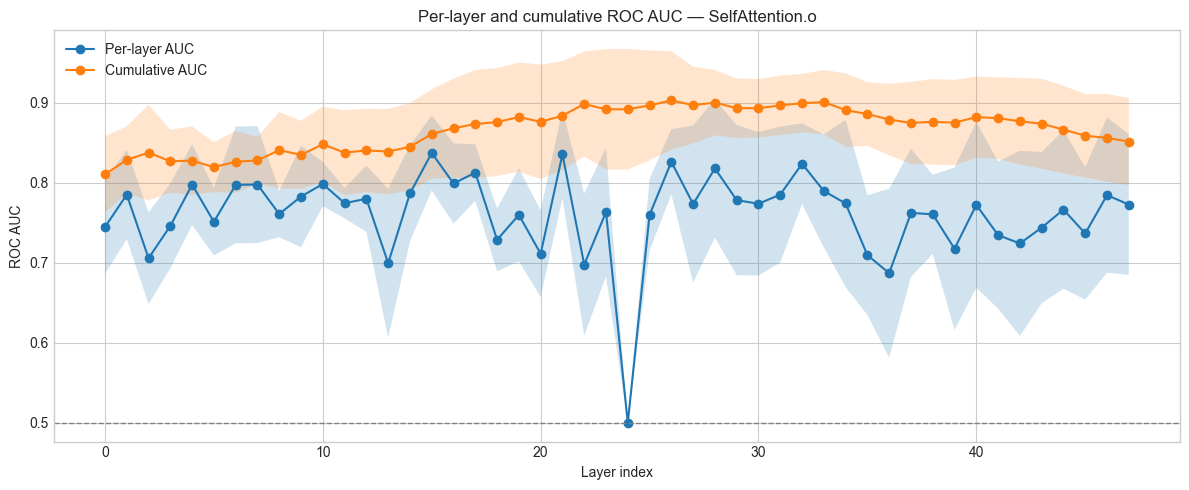

In [32]:
def cumulative_features(X, up_to_layer):
    return X[:, :up_to_layer, :].reshape(X.shape[0], -1)

cum_rows = []
for k in range(1, X_all.shape[1] + 1):
    X_cum = cumulative_features(X_all, k)
    pipe = make_auc_pipeline(X_cum.shape[1], CUMULATIVE_PCA_COMPONENTS)
    scores = cross_validate(pipe, X_cum, y_all, cv=cv, scoring=["roc_auc"], return_train_score=False)
    cum_rows.append({
        "layer_idx": k - 1,
        "layer_label": layer_labels[k - 1],
        "auc_mean": float(scores["test_roc_auc"].mean()),
        "auc_std": float(scores["test_roc_auc"].std(ddof=1)),
    })

cumulative_auc_df = pd.DataFrame(cum_rows)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(per_layer_auc_df["layer_idx"], per_layer_auc_df["auc_mean"], marker="o", label="Per-layer AUC")
ax.fill_between(per_layer_auc_df["layer_idx"], per_layer_auc_df["auc_mean"] - per_layer_auc_df["auc_std"], per_layer_auc_df["auc_mean"] + per_layer_auc_df["auc_std"], alpha=0.2)
ax.plot(cumulative_auc_df["layer_idx"], cumulative_auc_df["auc_mean"], marker="o", label="Cumulative AUC")
ax.fill_between(cumulative_auc_df["layer_idx"], cumulative_auc_df["auc_mean"] - cumulative_auc_df["auc_std"], cumulative_auc_df["auc_mean"] + cumulative_auc_df["auc_std"], alpha=0.2)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Per-layer and cumulative ROC AUC — {LAYER_NAME_FILTER}")
ax.set_xlabel("Layer index")
ax.set_ylabel("ROC AUC")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
def aligned_trajectory_distance(traj, proto):
    return float(np.linalg.norm(traj - proto, axis=1).mean())

def cosine_distance(a, b):
    return 1.0 - float(np.dot(a, b) / max(np.linalg.norm(a) * np.linalg.norm(b), 1e-12))

def dtw_trajectory_distance(traj, proto):
    n, m = len(traj), len(proto)
    dp = np.full((n + 1, m + 1), np.inf)
    dp[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = cosine_distance(traj[i - 1], proto[j - 1])
            dp[i, j] = cost + min(dp[i - 1, j], dp[i, j - 1], dp[i - 1, j - 1])
    return float(dp[n, m] / (n + m))

def cross_validated_prototype_auc(X, y, use_dtw=False):
    scores = np.zeros(len(X), dtype=float)
    for train_idx, test_idx in cv.split(np.zeros(len(y)), y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        proto0 = X_train[y_train == 0].mean(axis=0)
        proto1 = X_train[y_train == 1].mean(axis=0)
        for pos, idx in enumerate(test_idx):
            traj = X_test[pos]
            if use_dtw:
                d0 = dtw_trajectory_distance(traj, proto0)
                d1 = dtw_trajectory_distance(traj, proto1)
            else:
                d0 = aligned_trajectory_distance(traj, proto0)
                d1 = aligned_trajectory_distance(traj, proto1)
            scores[idx] = d0 - d1
    return float(roc_auc_score(y, scores)), scores

trajectory_auc_aligned, trajectory_scores_aligned = cross_validated_prototype_auc(X_all, y_all, use_dtw=False)
print(f"Prototype trajectory AUC (aligned) : {trajectory_auc_aligned:.4f}")

if RUN_DTW_TRAJECTORY:
    trajectory_auc_dtw, trajectory_scores_dtw = cross_validated_prototype_auc(X_all, y_all, use_dtw=True)
    print(f"Prototype trajectory AUC (DTW)     : {trajectory_auc_dtw:.4f}")

Prototype trajectory AUC (aligned) : 0.6978


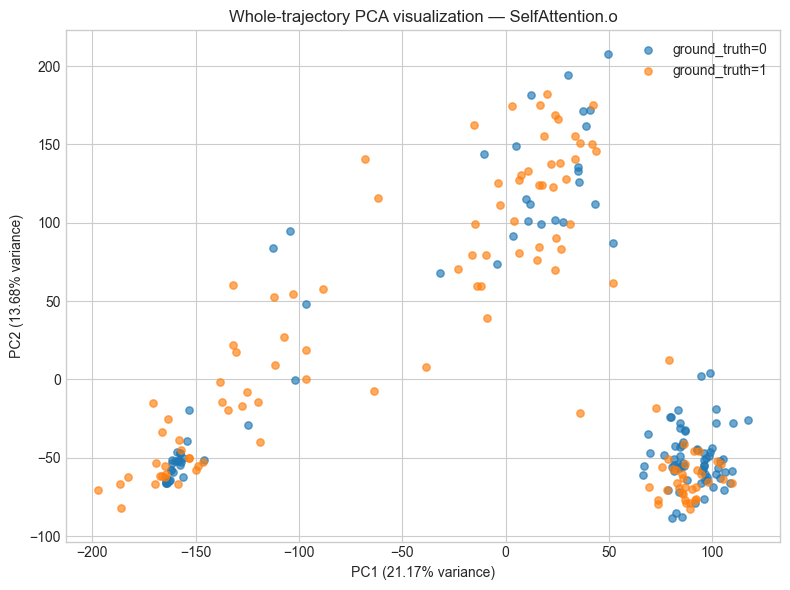

In [34]:
X_flat = X_all.reshape(X_all.shape[0], -1)
traj_pca = PCA(n_components=2, random_state=RANDOM_STATE)
traj_proj = traj_pca.fit_transform(StandardScaler().fit_transform(X_flat))
traj_var = traj_pca.explained_variance_ratio_ * 100.0

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(traj_proj[y_all == 0, 0], traj_proj[y_all == 0, 1], alpha=0.65, label=LABEL_0, s=28)
ax.scatter(traj_proj[y_all == 1, 0], traj_proj[y_all == 1, 1], alpha=0.65, label=LABEL_1, s=28)
ax.set_title(f"Whole-trajectory PCA visualization — {LAYER_NAME_FILTER}")
ax.set_xlabel(f"PC1 ({traj_var[0]:.2f}% variance)")
ax.set_ylabel(f"PC2 ({traj_var[1]:.2f}% variance)")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
summary_df = geometry_df.merge(per_layer_auc_df[["layer_idx", "auc_mean", "auc_std"]], on="layer_idx", how="left")
summary_cols = [
    "layer_idx", "layer_label", "layer_name",
    "auc_mean", "auc_std",
    "centroid_distance_subsample_mean",
    "between_to_within_subsample_mean",
    "fisher_ratio_subsample_mean",
    "energy_distance_subsample_mean",
    "mmd_rbf_subsample_mean",
    "subspace_cka_subsample_mean",
    "mean_principal_angle_deg_subsample_mean",
]

print(f"Aligned whole-trajectory prototype AUC: {trajectory_auc_aligned:.4f}")
display(summary_df[summary_cols].sort_values(["auc_mean", "fisher_ratio_subsample_mean"], ascending=False).head(20))

Aligned whole-trajectory prototype AUC: 0.6978


,layer_idx,layer_label,layer_name,auc_mean,auc_std,centroid_distance_subsample_mean,between_to_within_subsample_mean,fisher_ratio_subsample_mean,energy_distance_subsample_mean,mmd_rbf_subsample_mean,subspace_cka_subsample_mean,mean_principal_angle_deg_subsample_mean
15,15,L15,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.837500,0.046917,10.561273,0.105048,0.288356,2.458755,0.033006,0.562419,42.218852
21,21,L21,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.835764,0.055101,52.064931,0.083572,0.356351,10.631613,0.030211,0.548282,44.361148
26,26,L26,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.826389,0.040660,0.756293,0.145572,0.176224,0.177805,0.038209,0.734005,28.973501
32,32,L32,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.823958,0.050431,1.925545,0.314706,0.237175,0.634623,0.077838,0.725764,28.725565
28,28,L28,decoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.818056,0.086513,0.733660,0.022801,0.048550,0.118690,0.022311,0.811379,22.086393
17,17,L17,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.812847,0.035397,16.252508,0.101520,0.285544,3.753494,0.031736,0.523832,45.948678
16,16,L16,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.799306,0.050206,16.610138,0.091281,0.251480,3.761703,0.028986,0.545298,42.906624
10,10,L10,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.798611,0.027642,6.327619,0.126994,0.196493,1.769223,0.038788,0.590337,40.103505
4,4,L04,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.797917,0.050625,3.157038,0.100095,0.272664,0.847112,0.032012,0.504052,45.105333
7,7,L07,encoder.T5Block.T5LayerSelfAttention.SelfAtten...,0.797917,0.073109,5.001897,0.134545,0.222451,1.360901,0.040025,0.574237,39.554191
